# Whiteboard User Recognition Model

## Imports

In [30]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
NVIDIA GeForce RTX 4060 Laptop GPU


## Load Writer Dataset

### Dataset format
Supports two layouts:
- **IEEE DataPort** (`P1/D0/1.csv` …): 9-axis CSVs, first 6 columns used (accel + gyro, magnetometer dropped)
- **Production pen data** (`writer_name/sample_*.csv`): named columns `ax_g … gz_dps`

Point `DATASET_ROOT` at the folder containing the participant directories (`P1/`, `P2/`, …).

In [31]:
DATASET_ROOT = Path("datasets/Handwritten Digits Data/Handwritten Digits Data")  # folder containing P1/, P2/, ...

IMU_COLUMNS = ["ax_g", "ay_g", "az_g", "gx_dps", "gy_dps", "gz_dps"]

def load_segment_csv(path: Path) -> np.ndarray:
    df = pd.read_csv(path, comment="#")
    # Production pen format: named IMU columns
    if set(IMU_COLUMNS).issubset(df.columns):
        return df[IMU_COLUMNS].values.astype(np.float32)
    # IEEE DataPort format: columns are ax,ay,az,gx,gy,gz,mx,my,mz — take first 6
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] >= 6:
        return numeric.iloc[:, :6].values.astype(np.float32)
    raise ValueError(f"Cannot parse IMU columns from {path}")

def load_writer_dataset(root: Path):
    samples, labels = [], []
    for writer_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        for csv_path in sorted(writer_dir.rglob("*.csv")):
            samples.append(load_segment_csv(csv_path))
            labels.append(writer_dir.name)
    return samples, labels

all_samples, all_labels = load_writer_dataset(DATASET_ROOT)
writer_names  = sorted(set(all_labels))
writer_to_idx = {name: i for i, name in enumerate(writer_names)}
idx_to_writer = {i: name for name, i in writer_to_idx.items()}
label_ids     = [writer_to_idx[l] for l in all_labels]
num_writers   = len(writer_names)

print(f"Writers: {writer_names}")
print(f"Total samples: {len(all_samples)}")

Writers: ['P1', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P2', 'P20', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']
Total samples: 10000


## Preprocessing
Per-segment mean centering → append accel/gyro magnitudes (6→8 channels) → linear resample to 96 timesteps → per-channel z-score normalization (stats computed from training split only).

In [32]:
TARGET_LEN    = 96
MIN_TIMESTEPS = 16

def preprocess_segment(x: np.ndarray) -> np.ndarray:
    """(T, 6) → (TARGET_LEN, 8): mean-center + magnitudes + linear resample."""
    x = x.astype(np.float32)
    x[:, :3] -= x[:, :3].mean(axis=0)
    x[:, 3:] -= x[:, 3:].mean(axis=0)
    acc_mag = np.linalg.norm(x[:, :3], axis=1, keepdims=True)
    gyr_mag = np.linalg.norm(x[:, 3:], axis=1, keepdims=True)
    x = np.hstack([x, acc_mag, gyr_mag])          # (T, 8)
    t = x.shape[0]
    if t == TARGET_LEN:
        return x
    old_idx = np.linspace(0, 1, t)
    new_idx = np.linspace(0, 1, TARGET_LEN)
    out = np.zeros((TARGET_LEN, 8), dtype=np.float32)
    for i in range(8):
        out[:, i] = np.interp(new_idx, old_idx, x[:, i])
    return out

# Drop sequences that are too short
valid = [(s, l) for s, l in zip(all_samples, label_ids) if s.shape[0] >= MIN_TIMESTEPS]
samples_valid, labels_valid = zip(*valid)
samples_valid = list(samples_valid)
labels_valid  = list(labels_valid)
print(f"Valid samples (≥{MIN_TIMESTEPS} timesteps): {len(samples_valid)}")

# 80/20 train/val split (stratified by shuffle)
rng = np.random.default_rng(42)
idx = np.arange(len(samples_valid))
rng.shuffle(idx)
n_val     = max(1, int(math.floor(len(idx) * 0.2)))
val_idx   = idx[:n_val]
train_idx = idx[n_val:]

# Compute normalization stats from training split only
train_preprocessed = [preprocess_segment(samples_valid[i]) for i in train_idx]
stack        = np.concatenate(train_preprocessed, axis=0)
channel_mean = stack.mean(axis=0).astype(np.float32)
channel_std  = np.maximum(stack.std(axis=0), 1e-6).astype(np.float32)
print(f"channel_mean: {channel_mean.round(3)}")

Valid samples (≥16 timesteps): 10000
channel_mean: [ 0.001  0.001 -0.001 -0.    -0.     0.     0.85   0.25 ]


### Dataset class and DataLoaders

In [33]:
class WriterDataset(Dataset):
    def __init__(self, samples, label_ids, augment=False):
        self.samples   = samples
        self.label_ids = label_ids
        self.augment   = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        x = preprocess_segment(self.samples[i])
        x = (x - channel_mean) / channel_std
        if self.augment:
            # Jitter: small Gaussian noise in normalized space
            x = x + np.random.randn(*x.shape).astype(np.float32) * 0.05
            # Per-channel amplitude scale ±10%
            x = x * np.random.uniform(0.9, 1.1, (1, x.shape[1])).astype(np.float32)
            # Circular time shift ±5 timesteps
            x = np.roll(x, np.random.randint(-5, 6), axis=0)
        # Conv1d expects (C, T)
        return torch.from_numpy(x.T).float(), torch.tensor(self.label_ids[i], dtype=torch.long)

train_ds = WriterDataset([samples_valid[i] for i in train_idx], [labels_valid[i] for i in train_idx], augment=True)
val_ds   = WriterDataset([samples_valid[i] for i in val_idx],   [labels_valid[i] for i in val_idx],   augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)} samples | Val: {len(val_ds)} samples")

Train: 8000 samples | Val: 2000 samples


## Model Creation

In [49]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.proj(x)
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = self.drop(out)
        return F.gelu(out + identity)


class WriterEncoder(nn.Module):
    """Residual CNN + BiGRU with attention pooling → L2-normalized 128-dim embedding."""
    def __init__(self, in_channels=8, embed_dim=128):
        super().__init__()
        self.backbone = nn.Sequential(
            ResidualBlock(in_channels, 64),
            ResidualBlock(64, 96),
            ResidualBlock(96, 128),
        )
        self.bigru = nn.GRU(128, 96, num_layers=1, batch_first=True, bidirectional=True)
        self.proj  = nn.Linear(192, embed_dim)

    def forward(self, x):
        # x: (B, 8, T)
        feat = self.backbone(x)                    # (B, 128, T)
        seq  = feat.transpose(1, 2)                # (B, T, 128)
        gru_out, _ = self.bigru(seq)               # (B, T, 192)
        weights = torch.softmax(gru_out.pow(2).mean(dim=2), dim=1).unsqueeze(-1)
        pooled  = (gru_out * weights).sum(dim=1)   # (B, 192)
        return F.normalize(self.proj(pooled), p=2, dim=1)


class WriterIdNet(nn.Module):
    def __init__(self, num_writers, embed_dim=128):
        super().__init__()
        self.encoder    = WriterEncoder(embed_dim=embed_dim)
        self.classifier = nn.Linear(embed_dim, num_writers)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = WriterIdNet(num_writers=num_writers).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,} | Device: {device}")

Parameters: 421,620 | Device: cuda


In [50]:
def supcon_loss(emb, labels, temperature=0.1):
    """Supervised contrastive loss — pulls same-writer embeddings together in cosine space."""
    B = emb.size(0)
    sim = torch.mm(emb, emb.T) / temperature          # (B, B)

    pos_mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
    pos_mask.fill_diagonal_(0)                         # exclude self

    # Numerically stable log-softmax over all other samples
    sim_max, _ = sim.max(dim=1, keepdim=True)
    sim = sim - sim_max.detach()
    exp_sim = torch.exp(sim)
    eye = torch.eye(B, device=emb.device)
    log_prob = sim - torch.log((exp_sim * (1 - eye)).sum(dim=1, keepdim=True) + 1e-8)

    pos_count = pos_mask.sum(dim=1)
    valid = pos_count > 0
    loss_per = -(pos_mask * log_prob).sum(dim=1) / pos_count.clamp(min=1)
    return loss_per[valid].mean() if valid.any() else torch.zeros(1, device=emb.device).squeeze()


def run_epoch(model, loader, optimizer=None, label_smoothing=0.1, supcon_weight=0.5):
    training = optimizer is not None
    model.train(training)
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, emb = model(xb)
            ce   = F.cross_entropy(logits, yb, label_smoothing=label_smoothing if training else 0.0)
            loss = ce + supcon_weight * supcon_loss(emb, yb) if training else ce
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss    += ce.item() * len(yb)   # log CE only for readability
            total_correct += (logits.argmax(1) == yb).sum().item()
            total         += len(yb)
    return total_loss / total, total_correct / total

## Model Training

In [51]:
NUM_EPOCHS = 150
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1.0
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train {tr_loss:.4f}/{tr_acc:.3f} | val {vl_loss:.4f}/{vl_acc:.3f}")
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "style_best.pt")

print(f"\nBest val accuracy: {best_val_acc:.3f}")
model.load_state_dict(torch.load("style_best.pt", map_location=device))

Epoch 001 | train 2.9955/0.053 | val 2.9873/0.055
Epoch 010 | train 2.7726/0.116 | val 2.7296/0.102
Epoch 020 | train 2.5760/0.184 | val 2.5560/0.155
Epoch 030 | train 2.3267/0.296 | val 2.4256/0.235
Epoch 040 | train 2.0237/0.419 | val 2.2867/0.294
Epoch 050 | train 1.7376/0.533 | val 2.3157/0.316
Epoch 060 | train 1.5046/0.654 | val 2.3996/0.331
Epoch 070 | train 1.3120/0.751 | val 2.4598/0.333
Epoch 080 | train 1.1750/0.822 | val 2.5200/0.342
Epoch 090 | train 1.0877/0.866 | val 2.5762/0.355
Epoch 100 | train 1.0157/0.901 | val 2.6339/0.353
Epoch 110 | train 0.9721/0.921 | val 2.6545/0.353
Epoch 120 | train 0.9438/0.934 | val 2.6900/0.355
Epoch 130 | train 0.9258/0.946 | val 2.6956/0.356
Epoch 140 | train 0.9217/0.944 | val 2.6993/0.355
Epoch 150 | train 0.9209/0.945 | val 2.6967/0.355

Best val accuracy: 0.362


<All keys matched successfully>

## Learning Curves

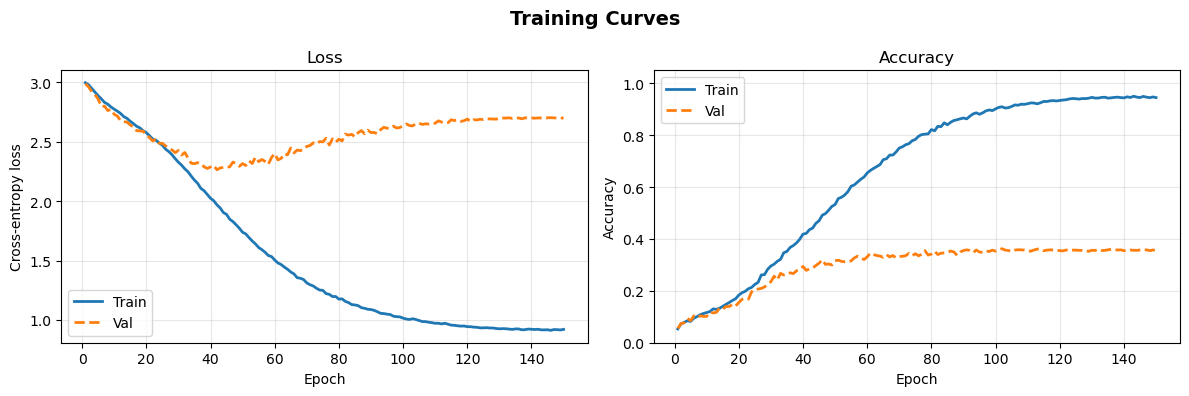

In [52]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs, history["val_loss"],   label="Val",   linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="Train", linewidth=2)
axes[1].plot(epochs, history["val_acc"],   label="Val",   linewidth=2, linestyle="--")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Prototype Gallery & Open-Set Inference
Build per-writer mean embeddings from training samples. Use cosine similarity + calibrated threshold for identification; scores below threshold → "Unknown". New writers can be enrolled without retraining.

Gallery: ['P1', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P2', 'P20', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']
Best threshold: 0.50  →  val accuracy: 0.348


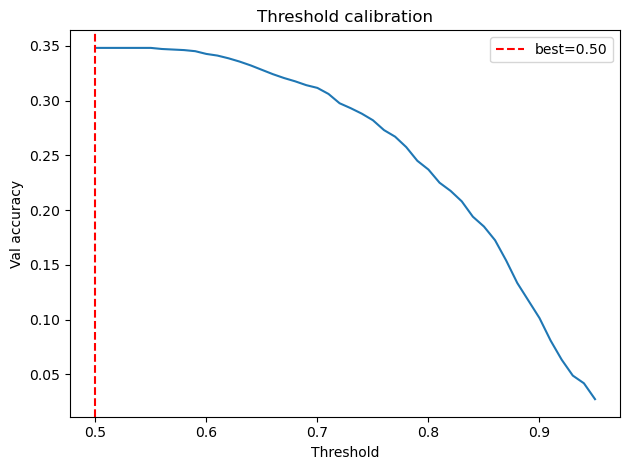

In [53]:
encoder = model.encoder.eval()

# --- Build prototype gallery from training samples ---

def embed_samples(sample_list):
    ds     = WriterDataset(sample_list, [0] * len(sample_list))
    loader = DataLoader(ds, batch_size=32)
    embs   = []
    with torch.no_grad():
        for xb, _ in loader:
            embs.append(encoder(xb.to(device)).cpu())
    return torch.cat(embs, dim=0)

gallery = {}
for writer_id, name in idx_to_writer.items():
    writer_samples = [samples_valid[i] for i in train_idx if labels_valid[i] == writer_id]
    if not writer_samples:
        continue
    embs  = embed_samples(writer_samples)
    proto = F.normalize(embs.mean(0, keepdim=True), p=2, dim=1).squeeze(0)
    gallery[name] = proto.cpu()

print("Gallery:", list(gallery.keys()))


# --- Predict a single sample ---

def predict(sample, threshold):
    x, _ = WriterDataset([sample], [0])[0]
    with torch.no_grad():
        emb = encoder(x.unsqueeze(0).to(device)).squeeze(0).cpu()
    best_name, best_sim = None, -1.0
    for name, proto in gallery.items():
        sim = float(torch.dot(emb, proto))
        if sim > best_sim:
            best_sim, best_name = sim, name
    return (best_name if best_sim >= threshold else "Unknown"), best_sim


# --- Calibrate threshold on validation set ---

thresholds = np.linspace(0.5, 0.95, 46)
accs = []
for thresh in thresholds:
    correct, total = 0, 0
    for i in val_idx:
        pred, _ = predict(samples_valid[i], thresh)
        if pred == idx_to_writer[labels_valid[i]]:
            correct += 1
        total += 1
    accs.append(correct / total)

best_thresh = float(thresholds[int(np.argmax(accs))])
best_acc    = max(accs)
print(f"Best threshold: {best_thresh:.2f}  →  val accuracy: {best_acc:.3f}")

plt.plot(thresholds, accs)
plt.axvline(best_thresh, color="red", linestyle="--", label=f"best={best_thresh:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Val accuracy")
plt.title("Threshold calibration"); plt.legend(); plt.tight_layout(); plt.show()


# --- Dynamically enroll a new writer (no retraining needed) ---

def enroll_new_writer(name: str, new_samples: list, momentum: float = 0.85):
    """Add or EMA-update a writer prototype in the gallery."""
    embs     = embed_samples(new_samples)
    new_proto = F.normalize(embs.mean(0, keepdim=True), p=2, dim=1).squeeze(0).cpu()
    if name in gallery:
        blended = momentum * gallery[name] + (1 - momentum) * new_proto
        gallery[name] = F.normalize(blended.unsqueeze(0), p=2, dim=1).squeeze(0)
    else:
        gallery[name] = new_proto
    print(f"Enrolled '{name}'  (gallery size: {len(gallery)})")

# Example:
# enroll_new_writer("alice", [some_sample_array, ...])

## Evaluation

Evaluating on 3 writers: ['P1', 'P10', 'P11']
Overall accuracy (3 writers): 0.551  |  threshold: 0.50


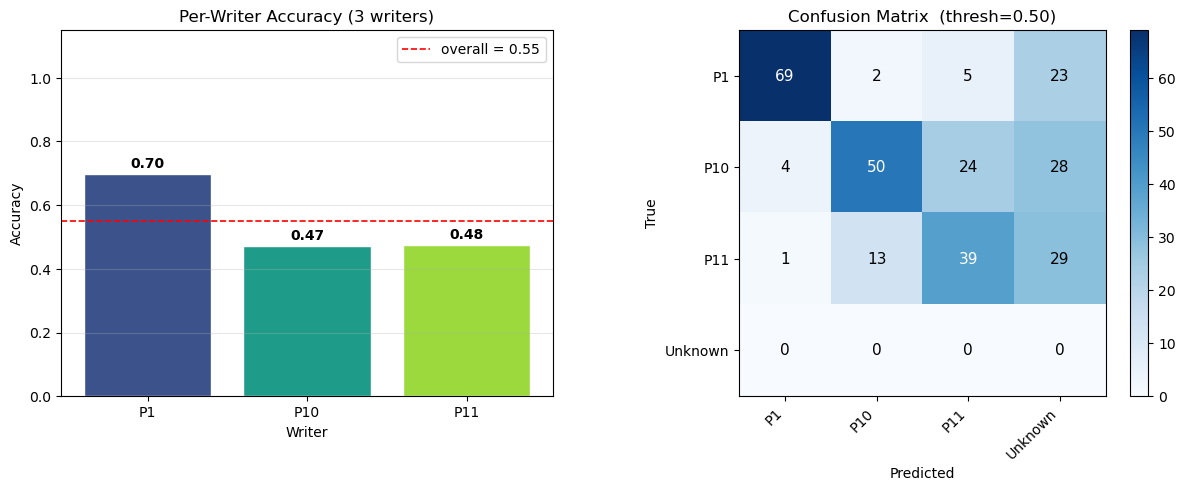

In [63]:
from collections import defaultdict
from sklearn.metrics import confusion_matrix

EVAL_WRITERS = 3   # simulate a small-group whiteboard session
eval_names   = sorted(gallery.keys())[:EVAL_WRITERS]
eval_gallery = {n: gallery[n] for n in eval_names}   # only these writers enrolled
eval_ids     = {writer_to_idx[n] for n in eval_names}
eval_val_idx = [i for i in val_idx if labels_valid[i] in eval_ids]

print(f"Evaluating on {len(eval_names)} writers: {eval_names}")

def predict_eval(sample, threshold):
    """Predict using only the eval-writer gallery."""
    x, _ = WriterDataset([sample], [0])[0]
    with torch.no_grad():
        emb = encoder(x.unsqueeze(0).to(device)).squeeze(0).cpu()
    best_name, best_sim = None, -1.0
    for name, proto in eval_gallery.items():
        sim = float(torch.dot(emb, proto))
        if sim > best_sim:
            best_sim, best_name = sim, name
    return (best_name if best_sim >= threshold else "Unknown"), best_sim

# --- Collect val-set predictions ---
per_writer_correct = defaultdict(int)
per_writer_total   = defaultdict(int)
y_true_all, y_pred_all = [], []

for i in eval_val_idx:
    true_name = idx_to_writer[labels_valid[i]]
    pred_name, _ = predict_eval(samples_valid[i], best_thresh)
    y_true_all.append(true_name)
    y_pred_all.append(pred_name)
    per_writer_total[true_name] += 1
    if true_name == pred_name:
        per_writer_correct[true_name] += 1

accs_per = [per_writer_correct[n] / per_writer_total[n] for n in eval_names]
overall  = sum(t == p for t, p in zip(y_true_all, y_pred_all)) / len(y_true_all)
print(f"Overall accuracy ({len(eval_names)} writers): {overall:.3f}  |  threshold: {best_thresh:.2f}")

colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(eval_names)))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Per-writer accuracy bar chart ---
axes[0].bar(eval_names, accs_per, color=colors, edgecolor="white")
axes[0].set_ylim(0, 1.15)
axes[0].set_xlabel("Writer"); axes[0].set_ylabel("Accuracy")
axes[0].set_title(f"Per-Writer Accuracy ({len(eval_names)} writers)")
for i, v in enumerate(accs_per):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[0].axhline(overall, color="red", linestyle="--", linewidth=1.2, label=f"overall = {overall:.2f}")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

# --- Confusion matrix (rows = true, cols = predicted; only eval writers + Unknown) ---
all_classes = eval_names + (["Unknown"] if "Unknown" in y_pred_all else [])
cm = confusion_matrix(y_true_all, y_pred_all, labels=all_classes)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(len(all_classes)))
axes[1].set_xticklabels(all_classes, rotation=45, ha="right", fontsize=10)
axes[1].set_yticks(range(len(all_classes)))
axes[1].set_yticklabels(all_classes, fontsize=10)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title(f"Confusion Matrix  (thresh={best_thresh:.2f})")
plt.colorbar(im, ax=axes[1], fraction=0.046)
half = cm.max() / 2
for r in range(len(all_classes)):
    for c in range(len(all_classes)):
        axes[1].text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=11,
                     color="white" if cm[r, c] > half else "black")

plt.tight_layout()
plt.savefig("writer_id_eval.png", dpi=120, bbox_inches="tight")
plt.show()

### Open-Set Evaluation (Unknown Rejection)
Leave-one-writer-out: for each writer, build a gallery from the other writers and test whether their samples are correctly rejected as "Unknown". Reports FAR, FRR, and EER across the threshold range.

**Requires a multi-writer dataset** — with only one writer the DET curve is degenerate.

Evaluating open-set on 3 writers: ['P1', 'P10', 'P11']
EER = 0.293  at threshold = 0.48
FAR @ EER: 0.291   FRR @ EER: 0.296


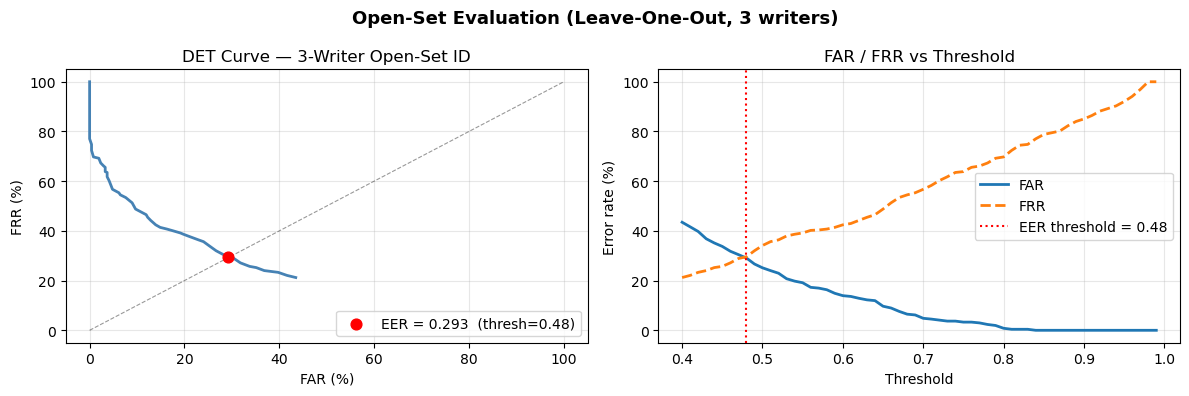

In [64]:
eval_name_to_id = {name: writer_to_idx[name] for name in eval_names}

if len(eval_names) < 2:
    print("Open-set evaluation requires ≥ 2 writers.")
else:
    print(f"Evaluating open-set on {len(eval_names)} writers: {eval_names}")
    thresholds_oo = np.linspace(0.40, 0.99, 60)
    far_curve = np.zeros(len(thresholds_oo))
    frr_curve = np.zeros(len(thresholds_oo))

    def predict_with_gallery(sample, threshold, gal):
        x, _ = WriterDataset([sample], [0])[0]
        with torch.no_grad():
            emb = encoder(x.unsqueeze(0).to(device)).squeeze(0).cpu()
        best_name, best_sim = None, -1.0
        for name, proto in gal.items():
            sim = float(torch.dot(emb, proto))
            if sim > best_sim:
                best_sim, best_name = sim, name
        return (best_name if best_sim >= threshold else "Unknown"), best_sim

    for leave_out_name, leave_out_id in eval_name_to_id.items():
        loo_gallery = {n: p for n, p in eval_gallery.items() if n != leave_out_name}
        impostor_idx = [i for i in val_idx if labels_valid[i] == leave_out_id]
        genuine_ids  = {eval_name_to_id[n] for n in eval_names if n != leave_out_name}
        genuine_idx  = [i for i in val_idx if labels_valid[i] in genuine_ids]
        for t_i, thresh in enumerate(thresholds_oo):
            fa = sum(1 for i in impostor_idx
                     if predict_with_gallery(samples_valid[i], thresh, loo_gallery)[0] != "Unknown")
            fr = sum(1 for i in genuine_idx
                     if predict_with_gallery(samples_valid[i], thresh, loo_gallery)[0] == "Unknown")
            far_curve[t_i] += fa / max(len(impostor_idx), 1)
            frr_curve[t_i] += fr / max(len(genuine_idx),  1)

    far_curve /= len(eval_names)
    frr_curve /= len(eval_names)

    eer_idx    = int(np.argmin(np.abs(far_curve - frr_curve)))
    eer_thresh = float(thresholds_oo[eer_idx])
    eer_val    = float((far_curve[eer_idx] + frr_curve[eer_idx]) / 2)
    print(f"EER = {eer_val:.3f}  at threshold = {eer_thresh:.2f}")
    print(f"FAR @ EER: {far_curve[eer_idx]:.3f}   FRR @ EER: {frr_curve[eer_idx]:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(far_curve * 100, frr_curve * 100, linewidth=2, color="steelblue")
    axes[0].scatter([far_curve[eer_idx] * 100], [frr_curve[eer_idx] * 100],
                    color="red", zorder=5, s=60, label=f"EER = {eer_val:.3f}  (thresh={eer_thresh:.2f})")
    axes[0].plot([0, 100], [0, 100], "k--", linewidth=0.8, alpha=0.4)
    axes[0].set_xlabel("FAR (%)"); axes[0].set_ylabel("FRR (%)")
    axes[0].set_title(f"DET Curve — {len(eval_names)}-Writer Open-Set ID")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(thresholds_oo, far_curve * 100, label="FAR", linewidth=2)
    axes[1].plot(thresholds_oo, frr_curve * 100, label="FRR", linewidth=2, linestyle="--")
    axes[1].axvline(eer_thresh, color="red", linestyle=":", linewidth=1.5,
                    label=f"EER threshold = {eer_thresh:.2f}")
    axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Error rate (%)")
    axes[1].set_title("FAR / FRR vs Threshold")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(f"Open-Set Evaluation (Leave-One-Out, {len(eval_names)} writers)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("open_set_eval.png", dpi=120, bbox_inches="tight")
    plt.show()

## Save as state dictionary or ONNX model

In [56]:
# Save encoder weights and normalization stats
torch.save(encoder.state_dict(), "style_encoder.pt")
np.save("style_channel_mean.npy", channel_mean)
np.save("style_channel_std.npy",  channel_std)

# Save gallery prototypes
torch.save({k: v.numpy() for k, v in gallery.items()}, "style_gallery.pt")

# ONNX export — input: (batch, channels=8, timesteps=96)
dummy = torch.randn(1, 8, TARGET_LEN, device=device)
torch.onnx.export(
    encoder,
    dummy,
    "style_encoder.onnx",
    opset_version=21,
    input_names=["imu_data"],
    output_names=["style_embedding"],
    dynamic_axes={"imu_data": {0: "batch_size"}},
)
print("Saved: style_encoder.pt, style_channel_mean.npy, style_channel_std.npy, style_gallery.pt, style_encoder.onnx")

C:\Users\aidan\AppData\Local\Temp\ipykernel_32472\1165295571.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `WriterEncoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `WriterEncoder([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `WriterEncoder([...]` with `torch.export.export(..., strict=True)`...


c:\Users\aidan\anaconda3\Lib\contextlib.py:162: UserWarning: The tensor attributes self.bigru._flat_weights[0], self.bigru._flat_weights[1], self.bigru._flat_weights[2], self.bigru._flat_weights[3], self.bigru._flat_weights[4], self.bigru._flat_weights[5], self.bigru._flat_weights[6], self.bigru._flat_weights[7] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  self.gen.throw(value)


[torch.onnx] Obtain model graph for `WriterEncoder([...]` with `torch.export.export(..., strict=True)`... ✅
[torch.onnx] Run decomposition...


c:\Users\aidan\anaconda3\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 9 of general pattern rewrite rules.
Saved: style_encoder.pt, style_channel_mean.npy, style_channel_std.npy, style_gallery.pt, style_encoder.onnx
